(780, 780)


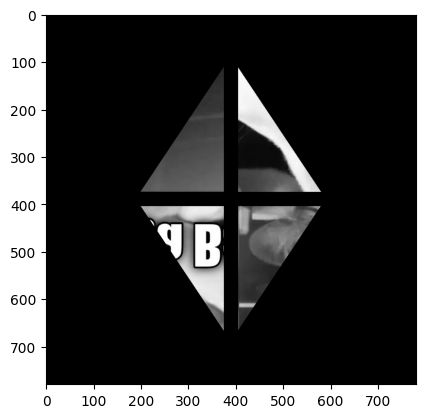

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

citra1 = plt.imread('Assets/citra1.png')
plt.imshow(citra1, cmap='gray')
print(citra1.shape)



(780, 780)


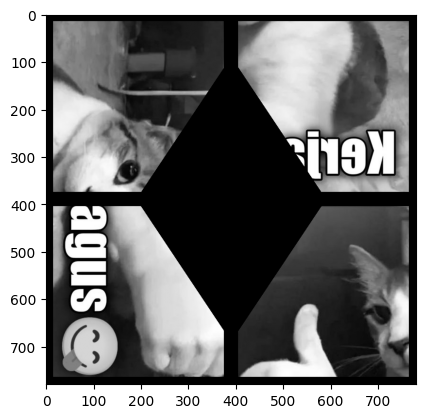

In [24]:
citra2 = plt.imread('Assets/citra2.png')
plt.imshow(citra2, cmap='gray')
print(citra2.shape)

## Digunakan unntuk menampilkan gambar citra 2

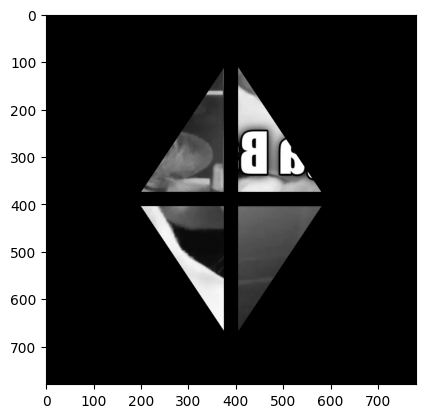

In [25]:
def rotasi(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0: return image
    elif val == 90: 
        rot = np.zeros ((w, h), dtype=image.dtype)
        for i in range (h):
            for j in range (w): rot [j, h -1 -i] = image [i,j]
            
        return rot
    elif val == 180:
        rot = np.zeros_like(image, dtype=image.dtype)
        for i in range (h):
            for j in range (w) : rot[h -1 - i, w - 1 -j]= image [i,j]
            
        return rot
    elif val == 270:
        rot = np.zeros ((w,h), dtype=image.dtype)
        for i in range (h):
            for j in range (w) : rot[w-1-j, i]= image[i,j]
            
        return rot
    
hasil = rotasi(citra1,180)
plt.imshow(hasil, cmap='gray')
plt.show()
    
   



Pada bagian pertama, says membuat sebuah fungsi untuk memutar posisi piksel gambar. Digunakan untuk memindahkan indeks baris dan kolom dari matriks asal ke matriks baru yang masih kosong (np.zeros). Misalnya, pada rotasi 180 derajat, posisi setiap piksel dibalik total baik secara horizontal maupun vertikal 

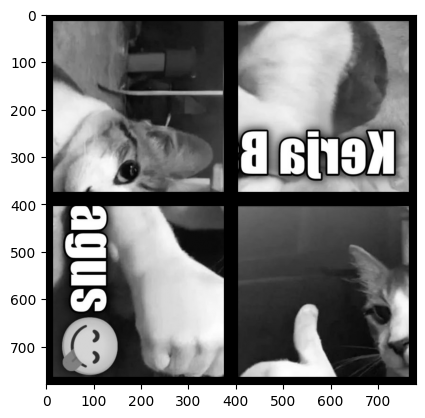

In [26]:
def bergabung(citra1, citra2):
    return citra1 + citra2
img1 = rotasi(citra1, 180)
img2 = citra2

hasil = bergabung(img1, img2)
plt.imshow(hasil, cmap='gray')
plt.show()

Setelah mendapatkan hasil rotasi, langkah selanjutnya adalah menggabungkan dua buah gambar hasil rotasi dan. Di sini, nilai intensitas warna dari setiap piksel yang berada di koordinat yang sama akan ditambahkan satu sama lain. Hasilnya adalah sebuah gambar campuran di mana objek dari kedua citra akan saling bertumpuk secara transparan.

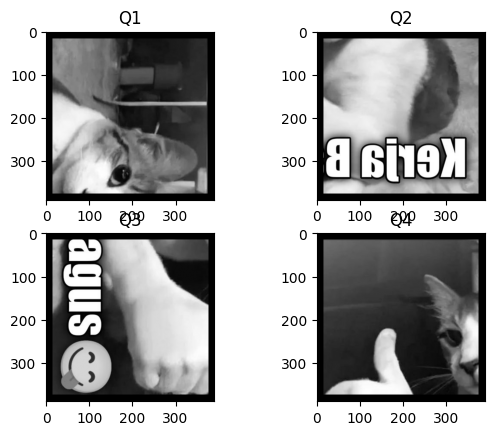

In [27]:
h,w = hasil.shape
h2,w2 = h//2, w//2

q1 = hasil[:h2, :w2]
q2 = hasil[:h2, w2:]
q3 = hasil[h2:, :w2]
q4 = hasil[h2:, w2:]

plt.subplot(2,2,1)
plt.imshow(q1, cmap='gray')
plt.title("Q1")

plt.subplot(2,2,2)
plt.imshow(q2, cmap='gray')
plt.title("Q2")

plt.subplot(2,2,3)
plt.imshow(q3, cmap='gray')
plt.title("Q3")

plt.subplot(2,2,4)
plt.imshow(q4, cmap='gray')
plt.title("Q4")

plt.show()


Pada bagian ini, gambar hasil penggabungan tersebut dibagi menjadi empat bagian yang sama besar, yang sering disebut sebagai kuadran. saya menentukan titik tengah secara vertikal dan horizontal dengan membagi dua dimensi gambar asli (h//2 dan w//2). Dengan teknik slicing pada array NumPy, saya memotong matriks tersebut menjadi empat wilayah: Q1 (kiri atas), Q2 (kanan atas), Q3 (kiri bawah), dan Q4 (kanan bawah).

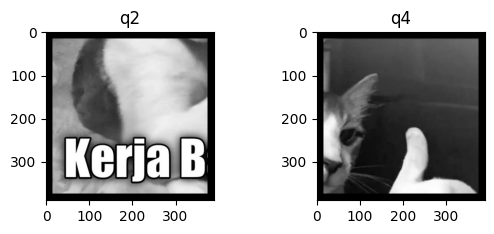

In [28]:
def fungsi_satu(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)

    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[i, w - 1 - j]
            elif mode == 'Y':
                hasil[i, j] = image[h - 1 - i, j]

    return hasil

q2 = fungsi_satu(q2, 'X')
q4 = fungsi_satu(q4, 'X')

plt.subplot(2,2,1)
plt.imshow(q2, cmap='gray')
plt.title("q2")

plt.subplot(2,2,2)
plt.imshow(q4, cmap='gray')
plt.title("q4")



plt.show()

Bagian ini  menampilkan keempat potongan gambar tadi ke dalam satu bingkai menggunakan plt.subplot(2,2,n). Fungsi ini mengatur tata letak tampilan agar menjadi grid dua baris dan dua kolom, sehingga saya bisa membandingkan setiap sudut dari gambar yang sudah dimodifikasi tersebut secara berdampingan dengan judul yang jelas untuk masing-masing bagian.

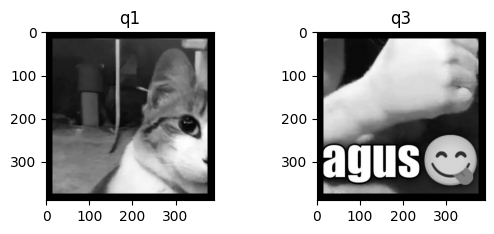

In [29]:
q1 = rotasi(q1, 270)
q3 = rotasi(q3, 270)

plt.subplot(2,2,1)
plt.imshow(q1, cmap='gray')
plt.title("q1")

plt.subplot(2,2,2)
plt.imshow(q3, cmap='gray')
plt.title("q3")

plt.show()



Pada bagian pertama, saya melakukan pemutaran ulang pada potongan gambar yang sudah dipotong sebelumnya. saya hanya memutar kuadran q1 dan q3 sejauh 270 derajat menggunakan fungsi rotasi yang sudah dibuat di awal. Setelah diputar, hasilnya ditampilkan berdampingan untuk melihat perubahan posisi piksel pada kedua area tersebut secara spesifik.

In [30]:
def fungsi_dua_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

def fungsi_dua_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil


fungsi_dua_b (Horisontal): Menyusun citra secara berdampingan (kiri-kanan). Lebar kanvas baru adalah jumlah lebar kedua gambar ($w1 + w2$).
fungsi_dua_c (Vertikal): Menumpuk citra secara atas-bawah. Tinggi kanvas baru adalah jumlah tinggi kedua gambar ($h1 + h2$).
Kedua fungsi ini menggunakan np.zeros untuk membuat "wadah" kosong terlebih dahulu sebelum menempelkan data piksel dari masing-masing citra ke posisi koordinat yang tepat.

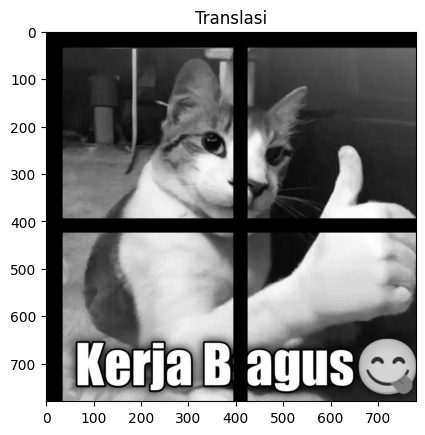

In [31]:
def fungsi_lima(image, geser_kolom_x=0, geser_baris_y=0):
    image = np.array(image)
    h, w = image.shape
    
    hasil = np.zeros((h, w), dtype=image.dtype)
    
    for i in range(h):
        for j in range(w):
            new_i = i + geser_baris_y
            new_j = j + geser_kolom_x
            
            if 0 <= new_i < h and 0 <= new_j < w:
                hasil[new_i, new_j] = image[i, j]
    
    return hasil

q1 = q1 * 255
q2 = q2 * 255
q3 = q3 * 255
q4 = q4 * 255

atas = fungsi_dua_b(q1, q4)
bawah = fungsi_dua_b(q2, q3)

hasil_akhir = fungsi_dua_c(atas, bawah)
hasil_translasi = fungsi_lima(hasil_akhir, 20, 20)

hasil_translasi = hasil_translasi * 255  

plt.imshow(hasil_translasi, cmap='gray')
plt.title("Translasi")
plt.show()

saya menyusun ulang kuadran yang tadinya terpisah (q1, q4, q2, q3) menjadi bentuk baru menggunakan fungsi penyambungan tadi.

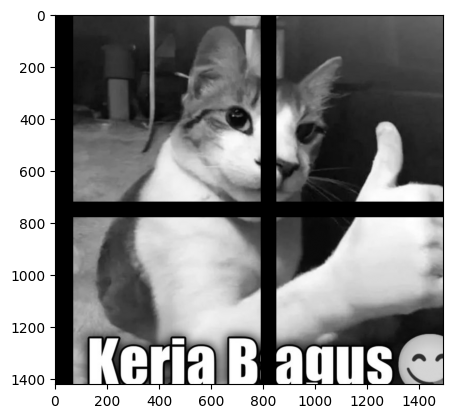

In [32]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    
    dilated = np.zeros((h * 2, w * 2)).astype(int)
    
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]

    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    
    return dilated[sy:ey, sx:ex]

hasil_dilatasi = fungsi_tiga(hasil_translasi, 70, 70, 00, 70)

plt.imshow(hasil_dilatasi, cmap='gray')
plt.show()

Gambar diperbesar 2 kali lipat dengan cara menduplikasi setiap piksel asal ke dalam area 2  x 2 piksel pada matriks baru (dilated).

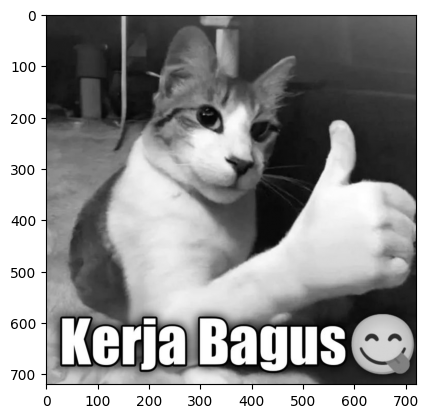

In [33]:
def hapus_border(image):
    rows = np.any(image != 0, axis=1)
    cols = np.any(image != 0, axis=0)
    return image[rows][:, cols]

q1 = hapus_border(q1)
q2 = hapus_border(q2)
q3 = hapus_border(q3)
q4 = hapus_border(q4)

atas = fungsi_dua_b(q1, q4)
bawah = fungsi_dua_b(q2, q3)

hasil_akhir = fungsi_dua_c(atas, bawah)

plt.imshow(hasil_akhir, cmap='gray')
plt.show()

Setelah menemukan batas piksel yang berisi data, fungsi akan memotong (crop) matriks sehingga hanya menyisakan area objek intinya saja. Hasilnya, setiap kuadran (q1 hingga q4) sekarang menjadi lebih "padat" tanpa ada tepian hitam yang mengganggu.

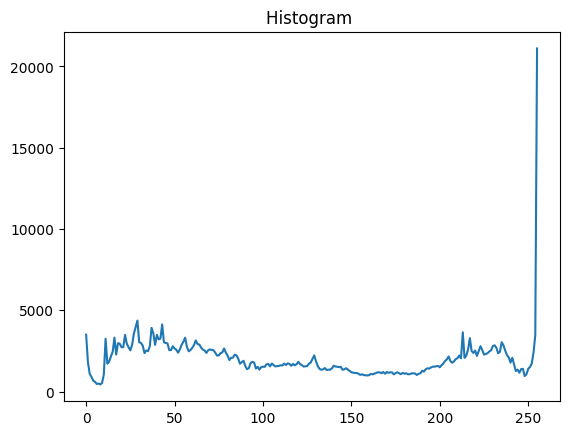

In [34]:
hist, bins = np.histogram(hasil_akhir.flatten(), bins=256, range=[0,256])

plt.plot(hist)
plt.title("Histogram ")
plt.show()

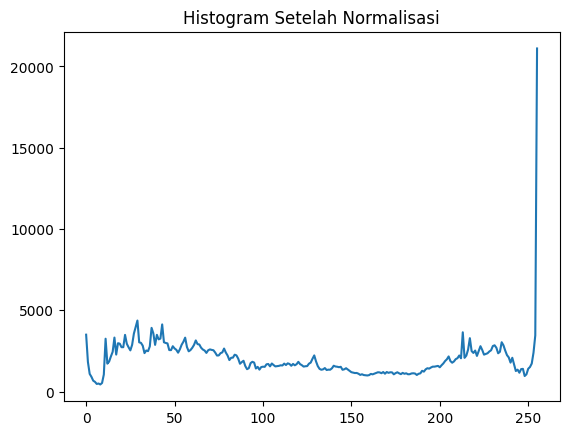

In [35]:
min_val = np.min(hasil_akhir)
max_val = np.max(hasil_akhir)

normalisasi = (hasil_akhir - min_val) / (max_val - min_val) * 255
normalisasi = normalisasi.astype(np.uint8)

hist2, bins2 = np.histogram(normalisasi.flatten(), bins=256, range=[0,256])

plt.plot(hist2)
plt.title("Histogram Setelah Normalisasi")
plt.show()